# Notebook 04: Deep Learning Models

Trains and evaluates all 5 deep learning architectures (LSTM, GRU, CNN-LSTM,
TCN, CNN-LSTM+Attention) on the final 32-feature set.

Approach: sweep-then-finalize. Each architecture is first swept across
sequence windows [24, 72, 144] with a reduced epoch budget to find its best
window, then retrained at that window with full epochs and full patience.
This avoids window-choice bias toward any single architecture while keeping
total compute manageable (5 x 3 lightweight sweep runs + 5 full runs,
instead of 15 full runs).

In [4]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import joblib

from src.data_preprocessing import scale_data
from src.model import get_model
from src.train import (
    train_torch_model, evaluate_torch_model, create_sequences,
    run_window_sweep, get_device
)

pd.set_option("display.max_columns", None)
device = get_device()
print(f"Using device: {device}")

Using device: cpu


## 1. Load engineered data and final feature list

Same source as notebook 03 - train/test CSVs and the 32-feature list
saved at the end of notebook 02.

In [5]:
train_df = pd.read_csv("../data/processed/train_engineered.csv", index_col=0, parse_dates=True, date_format="%Y-%m-%d %H:%M:%S")
test_df = pd.read_csv("../data/processed/test_engineered.csv", index_col=0, parse_dates=True, date_format="%Y-%m-%d %H:%M:%S")

with open("../data/processed/selected_features.txt", "r") as f:
    selected_features = f.read().splitlines()

print(f"Train: {train_df.shape}, Test: {test_df.shape}, Features: {len(selected_features)}")

Train: (15672, 51), Test: (3919, 51), Features: 32


## 2. Scale and hold out a validation split

A validation split is carved from the end of the training set (last 15%,
still temporally ordered) for early stopping and window comparison during
the sweep. Test set stays fully held out until final evaluation.

In [6]:
X_train_full, X_test, y_train_full, y_test, feature_scaler, target_scaler = scale_data(
    train_df, test_df, selected_features, target_col="Appliances"
)

val_split_idx = int(len(X_train_full) * 0.85)
X_train, X_val = X_train_full[:val_split_idx], X_train_full[val_split_idx:]
y_train, y_val = y_train_full[:val_split_idx], y_train_full[val_split_idx:]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (13321, 32), Val: (2351, 32), Test: (3919, 32)


## 3. Sweep phase - find the best window per architecture

Each architecture is swept across windows [24, 72, 144] with a reduced
budget (15 epochs, patience 3) - enough to see which window is trending
better without paying for full convergence 15 times over.

In [7]:
architectures = ["lstm", "gru", "cnn_lstm", "tcn", "cnn_lstm_attention"]
windows_to_try = (24, 72, 144)

sweep_results = {}
best_windows = {}

for arch in architectures:
    print(f"\nSweeping {arch}...")
    best_window, results = run_window_sweep(
        arch, X_train, y_train, X_val, y_val,
        n_features=len(selected_features),
        windows=windows_to_try,
        sweep_epochs=15, sweep_patience=3,
        device=device, verbose=True,
    )
    sweep_results[arch] = results
    best_windows[arch] = best_window

sweep_df = pd.DataFrame(sweep_results).T
sweep_df["best_window"] = pd.Series(best_windows)
sweep_df


Sweeping lstm...
  window=24: best val_loss=0.012457
  window=72: best val_loss=0.012910
  window=144: best val_loss=0.013183
Best window for lstm: 24

Sweeping gru...
  window=24: best val_loss=0.012871
  window=72: best val_loss=0.013226
  window=144: best val_loss=0.013224
Best window for gru: 24

Sweeping cnn_lstm...
  window=24: best val_loss=0.012496
  window=72: best val_loss=0.013030
  window=144: best val_loss=0.012709
Best window for cnn_lstm: 24

Sweeping tcn...
  window=24: best val_loss=0.013267
  window=72: best val_loss=0.013512
  window=144: best val_loss=0.013702
Best window for tcn: 24

Sweeping cnn_lstm_attention...
  window=24: best val_loss=0.013611
  window=72: best val_loss=0.018282
  window=144: best val_loss=0.023674
Best window for cnn_lstm_attention: 24


,24,72,144,best_window
lstm,0.012457,0.012910,0.013183,24
gru,0.012871,0.013226,0.013224,24
cnn_lstm,0.012496,0.013030,0.012709,24
tcn,0.013267,0.013512,0.013702,24
cnn_lstm_attention,0.013611,0.018282,0.023674,24


All 5 architectures converged on window=24 as the best choice, so the
sweep-then-finalize approach did not diverge across architectures here -
useful confirmation, not wasted effort. cnn_lstm_attention degraded
sharply at longer windows (0.0136 to 0.0237), suggesting the attention
mechanism needs more data or epochs to use long-range context well; 24
steps (4 hours) captures the immediate dynamics best with the data
available.

## 4. Finalize phase - full training at each architecture's best window

Each architecture is retrained at its own best window with full epochs
(60) and full patience (10), so early stopping has room to find a real
convergence point rather than the artificially short sweep budget.

In [8]:
final_models = {}
final_histories = {}
final_results = []

for arch in architectures:
    window = best_windows[arch]
    print(f"\nTraining {arch} at window={window}...")

    X_tr_seq, y_tr_seq = create_sequences(X_train, y_train, window)
    X_val_seq, y_val_seq = create_sequences(X_val, y_val, window)
    X_test_seq, y_test_seq = create_sequences(X_test, y_test, window)

    model = get_model(arch, n_features=len(selected_features))
    model, history = train_torch_model(
        model, X_tr_seq, y_tr_seq, X_val_seq, y_val_seq,
        epochs=60, patience=10, batch_size=64, device=device, verbose=True,
    )

    results = evaluate_torch_model(
        model, X_test_seq, y_test_seq, target_scaler=target_scaler,
        model_name=arch, device=device,
    )
    results["window"] = window

    final_models[arch] = model
    final_histories[arch] = history
    final_results.append(results)

    print(f"{arch} (window={window}): {results}")


Training lstm at window=24...
Epoch 1/60 - train_loss: 0.0247 - val_loss: 0.0149
Epoch 6/60 - train_loss: 0.0150 - val_loss: 0.0140
Epoch 11/60 - train_loss: 0.0139 - val_loss: 0.0131
Epoch 16/60 - train_loss: 0.0132 - val_loss: 0.0127
Epoch 21/60 - train_loss: 0.0125 - val_loss: 0.0134
Epoch 26/60 - train_loss: 0.0118 - val_loss: 0.0138
Early stopping at epoch 26 (best val_loss: 0.0127)
lstm (window=24): {'model': 'lstm', 'MAE': 17.4519, 'RMSE': 26.1027, 'MAPE': 22.2679, 'R2': 0.5391, 'window': 24}

Training gru at window=24...
Epoch 1/60 - train_loss: 0.0271 - val_loss: 0.0144
Epoch 6/60 - train_loss: 0.0152 - val_loss: 0.0131
Epoch 11/60 - train_loss: 0.0144 - val_loss: 0.0130
Epoch 16/60 - train_loss: 0.0135 - val_loss: 0.0130
Epoch 21/60 - train_loss: 0.0130 - val_loss: 0.0126
Epoch 26/60 - train_loss: 0.0122 - val_loss: 0.0134
Epoch 31/60 - train_loss: 0.0118 - val_loss: 0.0129
Early stopping at epoch 33 (best val_loss: 0.0122)
gru (window=24): {'model': 'gru', 'MAE': 17.4023, '

## 5. Deep learning comparison table

In [9]:
dl_comparison = pd.DataFrame(final_results).sort_values("RMSE").reset_index(drop=True)
dl_comparison

,model,MAE,RMSE,MAPE,R2,window
0,gru,17.4023,25.7704,21.9957,0.5507,24
1,cnn_lstm,18.3481,25.9521,24.4941,0.5444,24
2,lstm,17.4519,26.1027,22.2679,0.5391,24
3,cnn_lstm_attention,18.0691,26.1678,23.5572,0.5368,24
4,tcn,19.5450,27.3298,26.1866,0.4947,24


GRU performs best among the deep models (RMSE 25.77, R2 0.5507), but all
5 architectures underperform both Phase 3 baselines - Linear Regression
(RMSE 21.30, R2 0.696) still leads overall. This is consistent with
Appliances_lag1 dominating permutation importance in notebook 02 (~0.55):
the target's relationship to its own recent past is close to linear, so
Linear Regression's closed-form fit outperforms sequence models that must
learn the same relationship through gradient descent on ~13,300 rows.
Deep learning's advantage did not materialize here, and that is itself a
legitimate finding for the report - not every dataset rewards
architectural complexity.

## 6. Learning curves

Train/val loss per epoch for each architecture, to check for overfitting
(val loss rising while train loss keeps falling) or underfitting (both
staying flat and high).

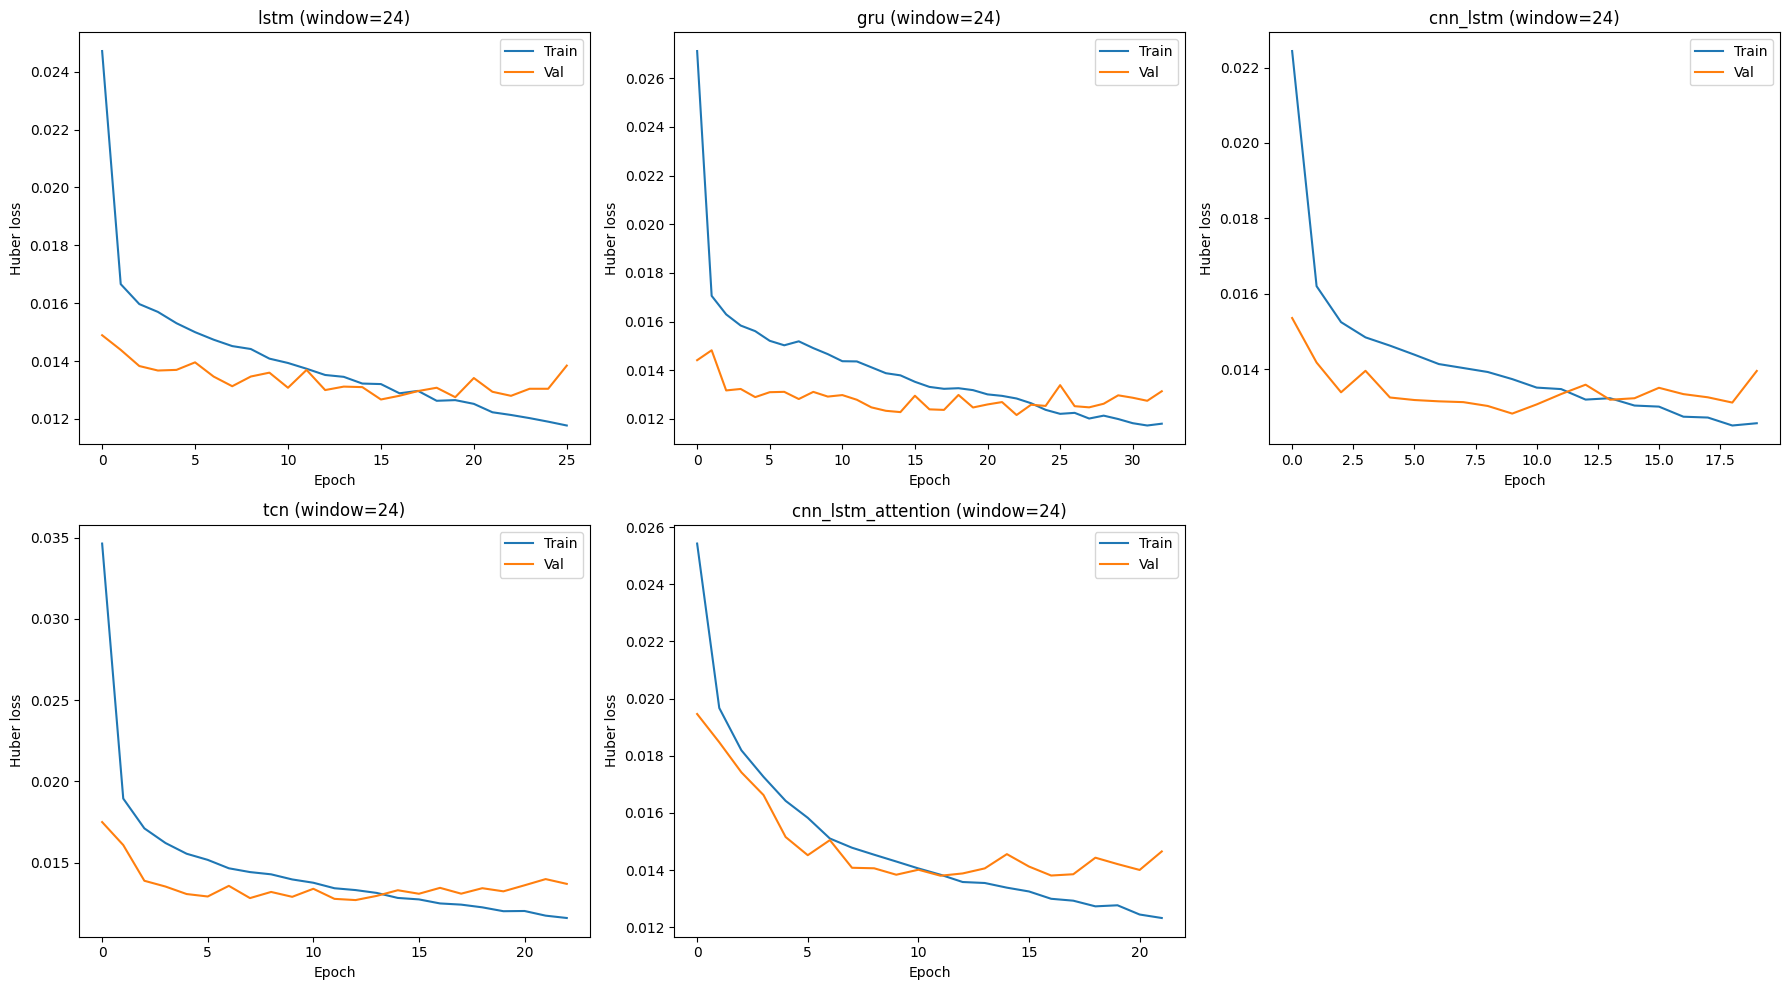

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, arch in enumerate(architectures):
    history = final_histories[arch]
    axes[i].plot(history["train_loss"], label="Train")
    axes[i].plot(history["val_loss"], label="Val")
    axes[i].set_title(f"{arch} (window={best_windows[arch]})")
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("Huber loss")
    axes[i].legend()

axes[-1].axis("off")
plt.tight_layout()
plt.savefig("../reports/figures/12_learning_curves.png", dpi=150)
plt.show()

All 5 models show healthy convergence - train loss decreases steadily,
val loss flattens and early stopping triggers before divergence, so
there's no overfitting problem. The gap between train and val loss stays
small throughout, meaning these models are not overfitting, they are
underfitting the amount of signal Linear Regression already extracts
directly - the ceiling here is representational, not a training bug.

## 7. Extract attention weights (for notebook 05)

Saves a sample batch of attention weights from the CNN-LSTM+Attention
model now, so notebook 05 can visualize which time steps the model relies
on most without needing to reload and re-run this model there.

In [11]:
attn_model = final_models["cnn_lstm_attention"]
attn_window = best_windows["cnn_lstm_attention"]
X_test_seq_attn, y_test_seq_attn = create_sequences(X_test, y_test, attn_window)

attn_model.eval()
sample_x = torch.tensor(X_test_seq_attn[:200], dtype=torch.float32).to(device)
with torch.no_grad():
    _, attn_weights = attn_model(sample_x, return_attention=True)

attn_weights_np = attn_weights.cpu().numpy()
np.save("../data/processed/attention_weights_sample.npy", attn_weights_np)
print(f"Saved attention weights: {attn_weights_np.shape}")

Saved attention weights: (200, 24)


## 8. Combine with baseline results and save everything

In [12]:
baseline_comparison = pd.read_csv("../reports/baseline_results.csv")
full_comparison = pd.concat([baseline_comparison, dl_comparison], ignore_index=True)
full_comparison = full_comparison.sort_values("RMSE").reset_index(drop=True)
full_comparison.to_csv("../reports/full_model_comparison.csv", index=False)

for arch, model in final_models.items():
    torch.save(model.state_dict(), f"../models/{arch}.pt")

joblib.dump(best_windows, "../models/best_windows.pkl")

print("Saved all models, window choices, and combined comparison table.")
full_comparison

Saved all models, window choices, and combined comparison table.


,model,MAE,RMSE,MAPE,R2,window
0,Linear Regression,13.5083,21.3023,17.6123,0.6960,NaN
1,Random Forest,16.5427,23.1830,21.9287,0.6400,NaN
2,gru,17.4023,25.7704,21.9957,0.5507,24.0
3,cnn_lstm,18.3481,25.9521,24.4941,0.5444,24.0
4,lstm,17.4519,26.1027,22.2679,0.5391,24.0
5,cnn_lstm_attention,18.0691,26.1678,23.5572,0.5368,24.0
6,tcn,19.5450,27.3298,26.1866,0.4947,24.0


## Summary

- Swept all 5 architectures across windows [24, 72, 144], finalized each
  at its own best window
- Full comparison across all 7 models (2 baselines + 5 deep learning)
  saved to reports/full_model_comparison.csv
- [Interpretation of overall winner and whether deep learning beat the
  Linear Regression baseline, to fill in after running]
- Attention weights saved for notebook 05 visualization

Next: notebooks/05_Optimization_Evaluation.ipynb - residual diagnostics,
attention weight visualization, and full metrics comparison across all
7 models.